<a href="https://colab.research.google.com/github/ShivaniMareddy/LLM/blob/main/LLM(BBC_news).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Load & Prepare Dataset

In [1]:
import pandas as pd
import re

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/MyDrive/bbc-text.csv'
df=pd.read_csv(path)
df.head()

Mounted at /content/drive


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [3]:
texts = df['text'].astype(str).tolist()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

texts = [clean_text(t) for t in texts]

print("Total Documents:", len(texts))

Total Documents: 2225


# Task 2: Create Vocabulary

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<unk>"
)

tokenizer.fit_on_texts(texts)

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 30342


# Task 3: Tokenization

In [21]:
sequences = tokenizer.texts_to_sequences(texts)

print(sequences[0][:20])

[178, 241, 7, 2, 1252, 4, 1234, 18, 126, 1146, 793, 1, 1284, 4156, 5, 216, 260, 4016, 1429, 77]


In [22]:
training_sequences = []

for seq in sequences:

    seq = seq[:50]   # limit length

    for i in range(1, len(seq)):
        training_sequences.append(
            (seq[:i], seq[i])
        )

print("Training Samples:", len(training_sequences))

Training Samples: 109025


# Task 4: Embedding Layer

In [23]:
import tensorflow as tf

embedding_dim = 128

embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)

# Task 5: Positional Encoding

In [24]:
import numpy as np

def positional_encoding(max_len, d_model):

    pos = np.arange(max_len)[:, np.newaxis]

    i = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(
        10000,
        (2 * (i // 2)) / np.float32(d_model)
    )

    angles = pos * angle_rates

    pe = np.zeros((max_len, d_model))

    pe[:, 0::2] = np.sin(angles[:, 0::2])

    pe[:, 1::2] = np.cos(angles[:, 1::2])

    return pe

pe = positional_encoding(50, 128)

print(pe.shape)

(50, 128)


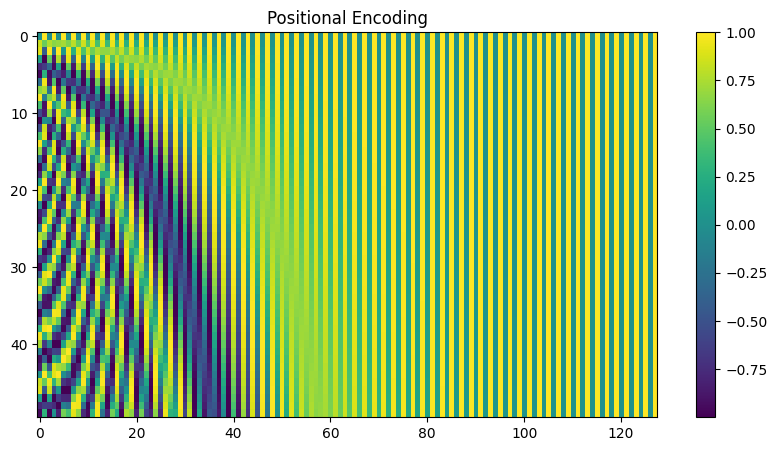

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(pe, aspect='auto')
plt.colorbar()
plt.title("Positional Encoding")
plt.show()

# Task 6: Masked Multi-Head Attention

In [26]:
seq_len = 50

mask = tf.linalg.band_part(
    tf.ones((seq_len, seq_len)),
    -1,
    0
)

print(mask.shape)

(50, 50)


# Task 7: GPT Decoder Block

In [27]:
class DecoderBlock(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads, ff_dim):

        super().__init__()

        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])

        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x):

        attn_output = self.att(
            x,
            x,
            use_causal_mask=True
        )

        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)

        x = self.norm2(x + ffn_output)

        return x

# Task 8: Stack Decoder Blocks

In [28]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X = []
y = []

for inp, target in training_sequences:
    X.append(inp)
    y.append(target)

max_len = max(len(seq) for seq in X)

X = pad_sequences(
    X,
    maxlen=max_len,
    padding='pre'
)

y = np.array(y)

print(X.shape)
print(y.shape)

(109025, 49)
(109025,)


In [29]:
inputs = tf.keras.Input(shape=(max_len,))

x = tf.keras.layers.Embedding(
    vocab_size,
    128
)(inputs)

x = DecoderBlock(128, 4, 256)(x)
x = DecoderBlock(128, 4, 256)(x)

x = tf.keras.layers.Lambda(
    lambda t: t[:, -1, :]
)(x)

outputs = tf.keras.layers.Dense(
    vocab_size,
    activation='softmax'
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 49, 128)        │     3,883,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_2 (DecoderBlock)  │ (None, 49, 128)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_3 (DecoderBlock)  │ (None, 49, 128)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30342)          │     3,914,118 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,458,374 (32.27 MB)

 Trainable params: 8,458,374 (32.27 MB)

 Non-trainable params: 0 (0.00 B)

# Task 9: Train Model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X,
    y,
    batch_size=128,
    epochs=15,
    validation_split=0.1
)

Epoch 1/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.1039 - loss: 6.5567 - val_accuracy: 0.1028 - val_loss: 6.2664
Epoch 2/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.1412 - loss: 5.8617 - val_accuracy: 0.1476 - val_loss: 5.7759
Epoch 3/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.1825 - loss: 5.2162 - val_accuracy: 0.1704 - val_loss: 5.3851
Epoch 4/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.2130 - loss: 4.5738 - val_accuracy: 0.1807 - val_loss: 5.2644
Epoch 5/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.2391 - loss: 4.0494 - val_accuracy: 0.1830 - val_loss: 5.2844
Epoch 6/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.2704 - loss: 3.5976 - val_accuracy: 0.1867 - val_loss: 5.3844
Epoch 7/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3107 - loss: 3.1894 - val_accuracy: 0.1873 - val_loss: 5.5516
Epoch 8/15
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3589 - loss: 2.8198 - 

# Task 10: Generate Text

In [31]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

prompt = "artificial intelligence"

generated = prompt

for _ in range(30):

    tokens = tokenizer.texts_to_sequences(
        [generated]
    )[0]

    padded = pad_sequences(
        [tokens],
        maxlen=max_len,
        padding='pre'
    )

    pred = model.predict(
        padded,
        verbose=0
    )[0]

    next_id = np.argmax(pred)

    next_word = tokenizer.index_word.get(
        next_id,
        ""
    )

    generated += " " + next_word

print("Generated Text:")
print(generated)

Generated Text:
artificial intelligence officer little him the last week of his <unk> was one player of the us of the us has been <unk> of various industries from the us book came in


# Evaluation (Perplexity)

In [32]:
import numpy as np

loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)

perplexity = np.exp(loss)

print("Loss:", loss)
print("Accuracy:", accuracy)
print("Perplexity:", perplexity)

Loss: 1.5530890226364136
Accuracy: 0.7133960127830505
Perplexity: 4.726046522366622


In [19]:
print(vocab_size)

30342


In [33]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

prompt = "artificial intelligence"

generated = prompt

for _ in range(30):

    tokens = tokenizer.texts_to_sequences([generated])[0]

    padded = pad_sequences(
        [tokens],
        maxlen=max_len,
        padding='pre'
    )

    pred = model.predict(padded, verbose=0)[0]

    next_id = np.argmax(pred)

    next_word = tokenizer.index_word.get(next_id, "<unk>")

    generated += " " + next_word

print("Generated Text:")
print(generated)

Generated Text:
artificial intelligence officer little him the last week of his <unk> was one player of the us of the us has been <unk> of various industries from the us book came in


In [35]:
test_prompts = [
    "artificial intelligence",
    "the government",
    "the company",
    "technology is",
    "the market"
]

for prompt in test_prompts:

    generated = prompt

    for _ in range(25):

        tokens = tokenizer.texts_to_sequences([generated])[0]

        padded = pad_sequences(
            [tokens],
            maxlen=max_len,
            padding='pre'
        )

        pred = model.predict(padded, verbose=0)[0]

        pred[tokenizer.word_index["<unk>"]] = 0

        next_id = np.argmax(pred)

        next_word = tokenizer.index_word.get(next_id, "<unk>")

        generated += " " + next_word

    print("\nPrompt:", prompt)
    print("Generated:", generated)
    print("-"*80)


Prompt: artificial intelligence
Generated: artificial intelligence officer little him the last week of his shock dubai winner of the dubai he was one of her birth of her birth mother told
--------------------------------------------------------------------------------

Prompt: the government
Generated: the government is to stop construction work in higher on thursday the national election and working on thursday little doubt that took over iraq and drive david
--------------------------------------------------------------------------------

Prompt: the company
Generated: the company backs of severe bill s press england s conduct following built a possible honours on monday cent has become the way a star michael ferguson
--------------------------------------------------------------------------------

Prompt: technology is
Generated: technology is set as part in social bond money an electronic arts ea says it wants to create a report the national company says it will only
-------------

In [36]:
def generate_text(prompt, max_words=40, temperature=0.7, top_k=5):

    generated = prompt

    for _ in range(max_words):

        tokens = tokenizer.texts_to_sequences([generated])[0]

        padded = pad_sequences(
            [tokens],
            maxlen=max_len,
            padding='pre'
        )

        pred = model.predict(padded, verbose=0)[0]

        unk_id = tokenizer.word_index.get("<unk>")
        if unk_id is not None and unk_id < len(pred):
            pred[unk_id] = 0

        pred = np.log(pred + 1e-10) / temperature
        pred = np.exp(pred)
        pred = pred / np.sum(pred)

        top_indices = np.argsort(pred)[-top_k:]
        top_probs = pred[top_indices]
        top_probs = top_probs / np.sum(top_probs)

        next_id = np.random.choice(
            top_indices,
            p=top_probs
        )

        next_word = tokenizer.index_word.get(next_id, "")

        generated += " " + next_word

    return generated

In [37]:
print(generate_text("artificial intelligence"))
print(generate_text("the government"))
print(generate_text("technology is"))

artificial intelligence officer was life to be made another book star michael douglas s berlin film in britain has was turned down at his late joy on a court of the star wars to direct the star michael howard who was drawn
the government s biggest music is to run as part in a us in charge of economics william american express themselves during the first real s most senior executives had west london school since the first ballot the first between and exchange
technology is set as part in your not to make any new da vinci code an electronic film about their competition at the french turned off the government film festival a boost film festival to be cut after an attempt to another
